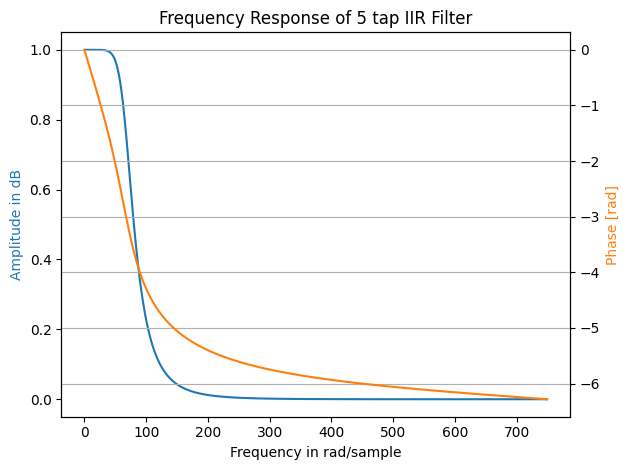

In [61]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp = 70
ws = 100
gpass = 3 #dB
gstop = 10 #dB

fs = 1500

b_coef, a_coef = signal.iirdesign(wp, ws, gpass, gstop, analog= False, ftype= 'butter', output= 'ba', fs= fs)

# los polos en radio unitario por estar en s (NO en z)

#al hacerlo en z (con analog false en lugar de true) me da de orden 3 en lugar de 4, 
#posiblemente por la compresion que genera el pasar de fs=500 a fs=2 pi
#al aumentar mi fs vuelvo a tener 4 polos ya que pasa a ser 'lineal' nuevamente 
#(porque deja de haber tanta compresion ya que la compresion esta muy lejos)
#lo que vimos de prewarping

taps = b_coef.shape[0]

omega, resp_freq = signal.freqz(b_coef, a=a_coef, worN= 1024, fs=fs)


fig, ax1 = plt.subplots(tight_layout=True)
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
#ax1.axvline(f_c, color='black', linestyle=':', linewidth=0.8)
ax1.plot(omega, abs(resp_freq), 'C0', label = 'Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlabel="Frequency in rad/sample", xlim=(0, np.pi))
ax2 = ax1.twinx() #para que tengan mismo eje x

phase = np.unwrap(np.angle(resp_freq))
#phase = np.angle(resp_freq) #el de angle es el que solemos usar pero scipy recomendaba unwrap

ax2.plot(omega, phase, 'C1',  label = 'Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.grid(True)
ax2.axis('tight')
plt.show()


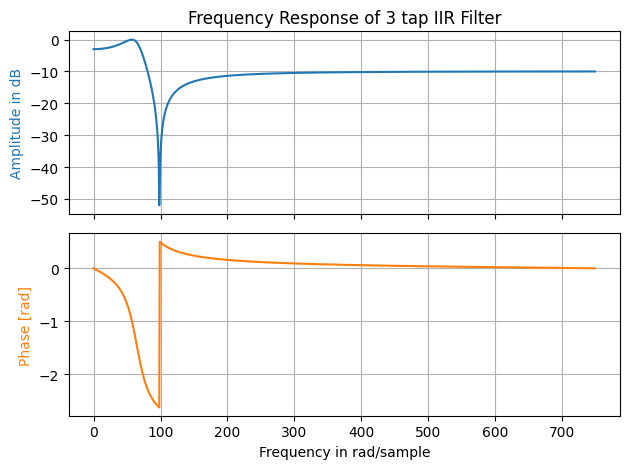

In [62]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp = 70
ws = 100
gpass = 3 #dB
gstop = 10 #dB

fs = 1500

b_coef, a_coef = signal.iirdesign(wp, ws, gpass, gstop, analog= False, ftype= 'cauer', output= 'ba', fs= fs)

taps = b_coef.shape[0]

omega, resp_freq = signal.freqz(b_coef, a=a_coef, worN= 1024, fs=fs)

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlim=(0, np.pi))
ax1.axis('tight')
ax1.grid(True)

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase, 'C1', label='Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.set_xlabel("Frequency in rad/sample")
ax2.axis('tight')
ax2.grid(True)

plt.show()


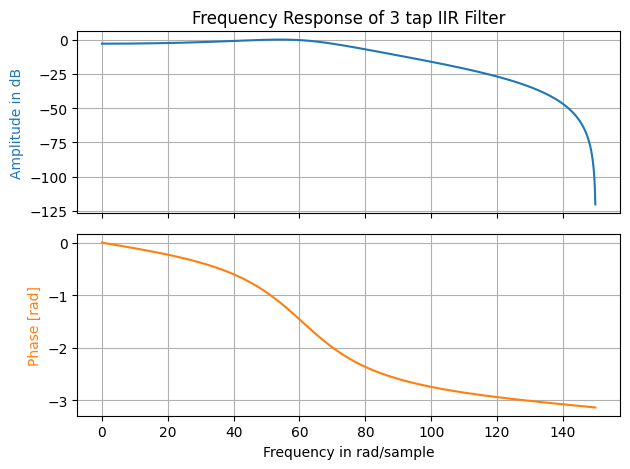

In [63]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp = 70
ws = 100
gpass = 3 #dB
gstop = 10 #dB

fs = 300

b_coef, a_coef = signal.iirdesign(wp, ws, gpass, gstop, analog= False, ftype= 'cheby1', output= 'ba', fs= fs)

taps = b_coef.shape[0]

omega, resp_freq = signal.freqz(b_coef, a=a_coef, worN= 1024, fs=fs)

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlim=(0, np.pi))
ax1.axis('tight')
ax1.grid(True)

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase, 'C1', label='Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.set_xlabel("Frequency in rad/sample")
ax2.axis('tight')
ax2.grid(True)

plt.show()

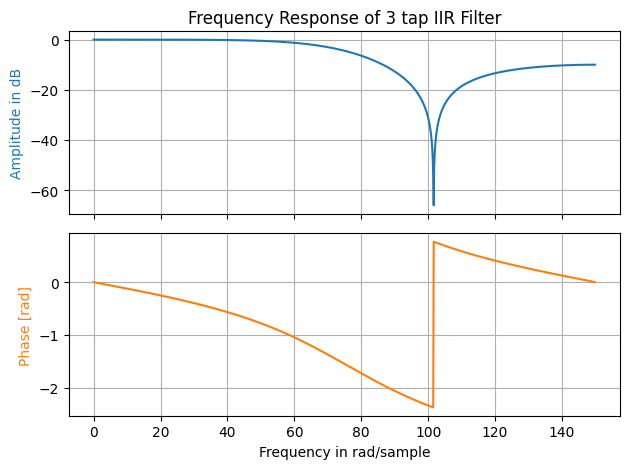

In [64]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp = 70
ws = 100
gpass = 3 #dB
gstop = 10 #dB

fs = 300

b_coef, a_coef = signal.iirdesign(wp, ws, gpass, gstop, analog= False, ftype= 'cheby2', output= 'ba', fs= fs)

taps = b_coef.shape[0]

omega, resp_freq = signal.freqz(b_coef, a=a_coef, worN= 1024, fs=fs)

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlim=(0, np.pi))
ax1.axis('tight')
ax1.grid(True)

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase, 'C1', label='Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.set_xlabel("Frequency in rad/sample")
ax2.axis('tight')
ax2.grid(True)

plt.show()

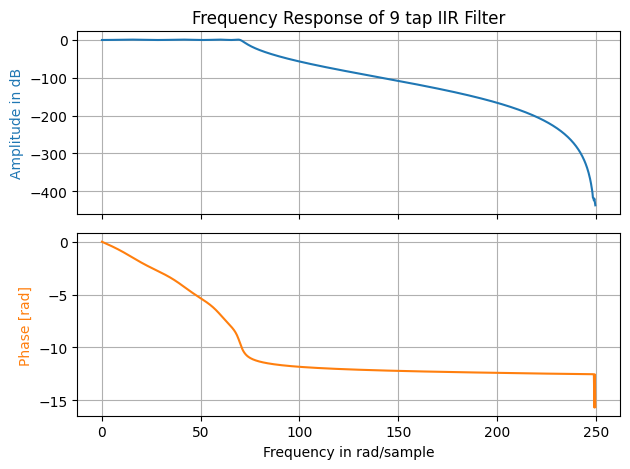

In [65]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp = 70
ws = 100 # Mantenemos diff
gpass = 1 #dB => lo bajamos
gstop = 50 #dB => Lo subimos

fs = 500

#ftype="butter"
ftype="cheby1"
#ftype="cheby2"
#ftype="butter"

b_coef, a_coef = signal.iirdesign(wp, ws, gpass, gstop, analog= False, ftype= ftype, output= 'ba', fs= fs)

taps = b_coef.shape[0]

omega, resp_freq = signal.freqz(b_coef, a=a_coef, worN= 1024, fs=fs)

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlim=(0, np.pi))
ax1.axis('tight')
ax1.grid(True)

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase, 'C1', label='Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.set_xlabel("Frequency in rad/sample")
ax2.axis('tight')
ax2.grid(True)

plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_9856\1474842065.py:33: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')


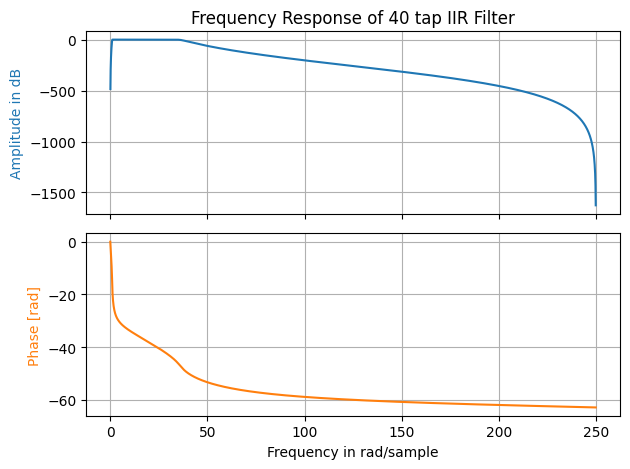

In [66]:
# Pasa Banda

from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp1 = 1
ws1 = 0.1
wp2 = 35
ws2 = 45
gpass = 1 #dB => lo bajamos
gstop = 40 #dB => Lo subimos

fs = 500

wp = [wp1, wp2] # banda de paso:  ws1 < wp1 < wp2 < ws2
ws = [ws1, ws2] # banda de stop

ftype="butter"
#ftype="cheby1"
#ftype="cheby2"
#ftype="cauer"

sos_coef = signal.iirdesign(wp, ws, gpass, gstop, analog=False, ftype=ftype, output='sos', fs=fs)

taps = sos_coef.shape[0] * 2

omega, resp_freq = signal.freqz_sos(sos_coef, worN=4096, fs=fs)

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlim=(0, np.pi))
ax1.axis('tight')
ax1.grid(True)

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase, 'C1', label='Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.set_xlabel("Frequency in rad/sample")
ax2.axis('tight')
ax2.grid(True)

plt.show()


C:\Users\MSI\AppData\Local\Temp\ipykernel_9856\1474842065.py:33: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')


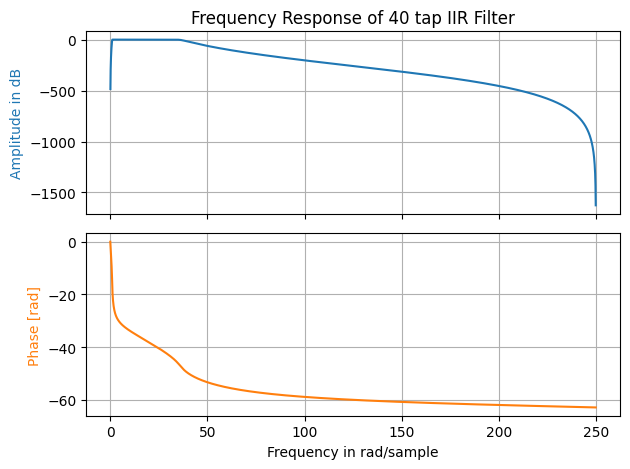

In [67]:
# Pasa Banda

from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

wp1 = 1
ws1 = 0.1
wp2 = 35
ws2 = 45
gpass = 1 #dB => lo bajamos
gstop = 40 #dB => Lo subimos

fs = 500

wp = [wp1, wp2] # banda de paso:  ws1 < wp1 < wp2 < ws2
ws = [ws1, ws2] # banda de stop

ftype="butter"
#ftype="cheby1"
#ftype="cheby2"
#ftype="cauer"

sos_coef = signal.iirdesign(wp, ws, gpass, gstop, analog=False, ftype=ftype, output='sos', fs=fs)

taps = sos_coef.shape[0] * 2

omega, resp_freq = signal.freqz_sos(sos_coef, worN=4096, fs=fs)

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, tight_layout=True)
ax1, ax2 = axs
ax1.set_title(f"Frequency Response of {taps} tap IIR Filter")
ax1.plot(omega, 20 * np.log10(abs(resp_freq)), 'C0', label='Modulo')
ax1.set_ylabel("Amplitude in dB", color='C0')
ax1.set(xlim=(0, np.pi))
ax1.axis('tight')
ax1.grid(True)

phase = np.unwrap(np.angle(resp_freq))

ax2.plot(omega, phase, 'C1', label='Fase')
ax2.set_ylabel('Phase [rad]', color='C1')
ax2.set_xlabel("Frequency in rad/sample")
ax2.axis('tight')
ax2.grid(True)

plt.show()
